In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
year=2021

In [3]:
nis_path = f'data/NIS{year}_Village_Year_Coords.xlsx'
nis = pd.read_excel(nis_path)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1449-T_Fe_Por_6-11,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2021,211,428,...,0,0,0,0,0,0,0,0,0,0
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2021,368,656,...,0,0,0,0,0,0,0,0,0,0
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2021,545,1195,...,0,0,0,0,0,0,0,0,0,0
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2021,217,440,...,0,0,0,0,0,0,0,0,0,0
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2021,230,742,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#Total population per village
nis["511-POP"] = nis["3-MAL_TOT"] + nis["2-FEM_TOT"]
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,1450-Souy_Fami,1451-T_Soury_Indig,1452-T_Fe_Soury_Indig,1453-T_Soury_6-11,1454-T_Fe_Soury_6-11,1455-T_Oth_Indig,1456-T_Fe_Oth_Indig,1457-T_Oth_6-11,1458-T_Fe_Oth_6-11,511-POP
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.0,1494700.0,2021,211,428,...,0,0,0,0,0,0,0,0,0,901
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.0,1494700.0,2021,368,656,...,0,0,0,0,0,0,0,0,0,2194
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.0,1494300.0,2021,545,1195,...,0,0,0,0,0,0,0,0,0,2432
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.0,1493500.0,2021,217,440,...,0,0,0,0,0,0,0,0,0,929
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.0,1494100.0,2021,230,742,...,0,0,0,0,0,0,0,0,0,1177


## Education module

In [5]:
#Illiterate population per village (women and men among 15 and 45 years)
nis["512-ILLITERATE_POP"] = nis["74-M_ILT15_17"] + nis["241-M_ILT18_24"]+nis["243-M_ILT25_35"]+nis["245-M_ILT36_45"] + nis["79-F_ILT15_17"]+nis["242-F_ILT18_24"]+nis["244-F_ILT25_35"]+nis["246-F_ILT36_45"]
nis["512-ILLITERATE_POP"].describe()

count    14490.000000
mean        26.441822
std         58.097522
min          0.000000
25%          0.000000
50%          2.000000
75%         27.000000
max       1211.000000
Name: 512-ILLITERATE_POP, dtype: float64

In [6]:
#Illiterate population rate per village
nis["513-ILLITERATE_RATE"] = (nis["512-ILLITERATE_POP"]/nis["511-POP"])*100
nis["511-POP"].describe()

#Comments: Literacy rate for youth and adult population is 91% and 86% in 2016 (https://uis.unesco.org/sites/default/files/documents/fs45-literacy-rates-continue-rise-generation-to-next-en-2017_0.pdf)
    #So there's two options: take the mean of adult and youth (11.5%) and take it as the threshold criteria for deprivation or divide it for age groups

count    14490.000000
mean      1156.043685
std        962.405017
min          0.000000
25%        613.000000
50%        925.000000
75%       1382.750000
max      19234.000000
Name: 511-POP, dtype: float64

In [7]:
print((nis["513-ILLITERATE_RATE"] == 0).sum())
print(nis["513-ILLITERATE_RATE"].isna().sum())

6938
12


## Health
### Child mortality

In [8]:
#Child mortality rate must be below 3.8%, the global rate between 2000-2015. Source:https://data.unicef.org/topic/child-survival/under-five-mortality/#:~:text=The%20global%20under%2Dfive%20mortality,a%20matter%20of%20urgent%20concern.

#Child mortality rate per village

nis["522-POB_UD5yrs"]=nis["201-MAL_0_2"]+nis["202-FEM_0_2"]+nis["203-MAL_3_4"]+nis["204-FEM_3_4"]+nis["205-MAL_5"]+nis["206-FEM_5"]
nis["523-C_MORT_RATE"]=nis["373-TOT_UD5_die"]/nis["522-POB_UD5yrs"]*100
pd.set_option("display.float_format", "{:.6f}".format)

nis["523-C_MORT_RATE"].describe()

count   14476.000000
mean        0.059694
std         0.688536
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        66.666667
Name: 523-C_MORT_RATE, dtype: float64

In [9]:
print((nis["366-KM_Heal_cent"] == 0).sum())
print(nis["366-KM_Heal_cent"].isna().sum())

998
0


## Living standards module
### Drinking water

In [10]:
#The deprivation threshold criteria will be under 71% (average between 69 and 73, data of 2015 and 2022 data), in which the village has less than a 71% of families with improved sources of water rate, it's considered deprived
    #Source: https://sdgs.un.org/goals/goal6#progress_and_info


#Source of drinking water is improved (purified systems, pump, mixed wells) or unimproved (pond, river, lakes, natural ponds, etc)

nis["514-IMPROV_WAT"] = nis["391-Wat_pur"] + nis["392-Wat_well"]
#Family responses related to source of drinking water 
nis["524-Fam_Wat_Res"]=nis["391-Wat_pur"] + nis["392-Wat_well"]+nis["394-Wat_pond"] + nis["396-Wat_river"]

#Rate of families with improved water 
nis["515-IMPROV_WAT_RATE"]=nis["514-IMPROV_WAT"]/nis["1-FAMILY"]*100
nis["516-UNIMPROV_WAT"] = nis["394-Wat_pond"] + nis["1-FAMILY"]

#Rate of families with unimproved water 
nis["517-UNIMPROV_WAT_RATE"]=nis["516-UNIMPROV_WAT"]/nis["1-FAMILY"]*100
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,511-POP,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2021,211,428,...,901,25,2.774695,91,0.000000,60,211,28.436019,258,122.274882
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2021,368,656,...,2194,0,0.000000,176,0.000000,0,363,0.000000,731,198.641304
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2021,545,1195,...,2432,0,0.000000,223,0.000000,420,528,77.064220,557,102.201835
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2021,217,440,...,929,26,2.798708,102,0.000000,102,217,47.004608,219,100.921659
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2021,230,742,...,1177,0,0.000000,174,0.000000,167,230,72.608696,293,127.391304


In [11]:
print((nis["514-IMPROV_WAT"] == 0).sum())
print(nis["514-IMPROV_WAT"].isna().sum())

1038
0


In [12]:
print((nis["515-IMPROV_WAT_RATE"] == 0).sum())
print(nis["515-IMPROV_WAT_RATE"].isna().sum())

1026
12


In [13]:
nis["515-IMPROV_WAT_RATE"].describe()

count   14478.000000
mean       69.984526
std        36.005107
min         0.000000
25%        41.756362
50%        90.058680
75%       100.000000
max       100.000000
Name: 515-IMPROV_WAT_RATE, dtype: float64

In [83]:
#Creating dummy for variable of unimproved source of water (517-FAM_UNIMPROV_WAT_RATE)
    # takes the value of 1 if more than 50% of the families have an unimproved sources of water

#nis["525-UNIMPROV_WAT_DUM"] = (nis["517-FAM_UNIMPROV_WAT_RATE"] >= 50).astype(int)
#nis["525-UNIMPROV_WAT_DUM"].describe()

### Electricity

In [14]:
#Global electricity access in 2022 is 91% (https://sdgs.un.org/goals/goal7#progress_and_info)

#Rate of houses that have electricity
nis["528-Elec_Rate"]=nis["330-Villa_R_Elec"] / nis["1-FAMILY"]*100

nis.describe()

,VillGis,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,2-FEM_TOT,73-F_HHH,201-MAL_0_2,202-FEM_0_2,...,512-ILLITERATE_POP,513-ILLITERATE_RATE,522-POB_UD5yrs,523-C_MORT_RATE,514-IMPROV_WAT,524-Fam_Wat_Res,515-IMPROV_WAT_RATE,516-UNIMPROV_WAT,517-UNIMPROV_WAT_RATE,528-Elec_Rate
count,14490.000000,11963.000000,11963.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,14490.000000,...,14490.000000,14478.000000,14490.000000,14476.000000,14490.000000,14490.000000,14478.000000,14490.000000,14478.000000,14478.000000
mean,11524838.127191,464122.048232,1335548.697066,2021.000000,263.053899,568.176743,587.866943,39.539476,24.577709,24.495721,...,26.441822,2.610747,134.285438,0.059694,190.503244,229.591649,69.984526,282.990683,108.800050,0.359742
std,7292707.859964,99403.056032,109523.986424,0.000000,207.981286,488.473927,492.214811,45.983691,24.716002,23.595213,...,58.097522,5.263531,128.475580,0.688536,207.810556,205.232890,36.005107,221.983823,21.684681,2.478383
min,1020101.000000,0.000000,0.000000,2021.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
25%,5050403.250000,414891.500000,1247194.500000,2021.000000,141.000000,299.000000,312.000000,16.000000,11.000000,11.000000,...,0.000000,0.000000,63.000000,0.000000,68.000000,112.000000,41.756362,151.000000,100.000000,0.000000
50%,12020702.500000,470716.000000,1302872.000000,2021.000000,214.000000,452.000000,471.000000,29.000000,18.000000,18.000000,...,2.000000,0.203978,102.000000,0.000000,147.000000,183.000000,90.058680,229.000000,100.000000,0.000000
75%,17100504.750000,522478.000000,1428018.000000,2021.000000,320.000000,679.000000,704.000000,48.000000,30.000000,30.000000,...,27.000000,2.788114,163.000000,0.000000,249.000000,285.750000,100.000000,347.000000,102.476788,0.000000
max,25071415.000000,770884.000000,1594700.000000,2021.000000,3845.000000,16089.000000,10252.000000,2472.000000,840.000000,415.000000,...,1211.000000,51.698806,2896.000000,66.666667,3845.000000,3845.000000,100.000000,3845.000000,200.000000,94.690265


In [86]:
#Creating a dummy for village houses with electricity (330-Villa_R_Elec), 
    # takes the value of 1 if none village houses has electricity

#nis["330-Villa_R_Elec"].describe()
#nis["523-Elec_DUM"]= (nis["330-Villa_R_Elec"] == 0).astype(int)
 

### Housing quality (roof)

In [15]:
#Materials of roof are High Quality (tiled and zinc or fibro) or Low Quality (Thatched) among houses that have electricity
nis["518-HQ_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]

#Total of roof materials 
nis["525-TOT_ROOF"]=nis["326-Z_Fib_R_Elec"] + nis["327-Til_R_Elec"]+nis["325-THAT_R_Elec"]

#Rate of High Quality (HQ) roofs 
# nis["519-HQ_ROOF_RATE"]=nis["518-HQ_ROOF"] / nis["525-TOT_ROOF"]*100

#Rate of Low Quality (LQ) roofs 
# nis["526-LQ_ROOF_RATE"]=nis["325-THAT_R_Elec"] / nis["525-TOT_ROOF"]*100

#Only about 66% of housing units are built with durable material for roof, wall, or floor (p. 19 - https://documents1.worldbank.org/curated/en/370141635794493951/pdf/Introducing-the-Adequate-Housing-Index-AHI-A-New-Approach-to-Estimate-the-Adequate-Housing-Deficit-within-and-across-Emerging-Economies.pdf)
# And electricity access is 91% https://sdgs.un.org/goals/goal7#progress_and_info

#Rate of High Quality (HQ) roofs with electricity
nis["533-HQ_ROOF_ELEC_RATE"]=(nis["518-HQ_ROOF"] / nis["1-FAMILY"])*100
nis["534-LQ_ROOF_ELEC_RATE"]=(nis["325-THAT_R_Elec"] / nis["1-FAMILY"])*100

nis["534-LQ_ROOF_ELEC_RATE"].describe()

count   14478.000000
mean        0.437461
std         2.326390
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        83.571429
Name: 534-LQ_ROOF_ELEC_RATE, dtype: float64

In [16]:
print((nis["533-HQ_ROOF_ELEC_RATE"] == 0).sum())
print(nis["533-HQ_ROOF_ELEC_RATE"].isna().sum())

709
12


In [17]:
nis["1-FAMILY"].describe()

count   14490.000000
mean      263.053899
std       207.981286
min         0.000000
25%       141.000000
50%       214.000000
75%       320.000000
max      3845.000000
Name: 1-FAMILY, dtype: float64

In [91]:
#Creating dummy for variable of low quality materials of roof (526-LQ_ROOF)
    # takes the value of 1 if more than 50% of the families have roof with low quality materials
#nis["527-LQ_ROOF_DUM"] = (nis["526-LQ_ROOF"] >= 50).astype(int)

#nis["527-LQ_ROOF_DUM"].describe()

### Assets ownership

In [18]:
#### Mobility assets 
    #Assets considered by NIS (moto and motor tri-cycle) 
nis["520-MOB_ASSETS"] = nis["30-MOTO_NUM"] + nis["355-Mot_Tricyc_NUM"]
nis["521-MOB_ASSETS_RATE"]=nis["520-MOB_ASSETS"]/nis["511-POP"]*100

#Families that own an cultivated land
nis["529-CULT_LAND"] = nis["1-FAMILY"] - nis["289-No_F_Land"]

### Agricultural assets (number of families that have irrigation wells, pigs, goat/sheep, chicken, duck, crocodiles, own cultivated land). 
nis["530-AGRI_ASSETS"] = nis["529-CULT_LAND"] + nis["282-Own_IRRI_Wells"]+nis["297-Goat_fami"]+nis["299-Chick_fami"]+nis["302-Duck_fami"]+nis["316-Croco_fami"]
nis["531-AGRI_ASSETS_RATE"]=nis["530-AGRI_ASSETS"]/nis["1-FAMILY"]*100
        #Revisar  
nis["531-AGRI_ASSETS_RATE"].describe()


count   14478.000000
mean      149.428120
std        52.696525
min         0.000000
25%       105.657176
50%       155.013228
75%       190.472527
max       341.686747
Name: 531-AGRI_ASSETS_RATE, dtype: float64

In [19]:
print((nis["521-MOB_ASSETS_RATE"] == 0).sum())
print(nis["521-MOB_ASSETS_RATE"].isna().sum())

112
12


In [20]:

nis["521-MOB_ASSETS_RATE"].describe()

count   14478.000000
mean       20.473577
std         9.782113
min         0.000000
25%        15.477671
50%        20.201457
75%        24.193548
max       278.774929
Name: 521-MOB_ASSETS_RATE, dtype: float64

### Sanitation

In [21]:
#Rate of houses that have latrines
nis["532-Sanit_Rate"]=100-(nis["23-TOILET"] / nis["1-FAMILY"]*100)
nis.head()

,VillGis,Province,District,Commune,Village,XPHUM,YPHUM,Year,1-FAMILY,3-MAL_TOT,...,518-HQ_ROOF,525-TOT_ROOF,533-HQ_ROOF_ELEC_RATE,534-LQ_ROOF_ELEC_RATE,520-MOB_ASSETS,521-MOB_ASSETS_RATE,529-CULT_LAND,530-AGRI_ASSETS,531-AGRI_ASSETS_RATE,532-Sanit_Rate
0,1020101,Banteay Meanchey,Mongkol Borei,Banteay Neang,Ou Thum,287800.000000,1494700.000000,2021,211,428,...,162,162,76.777251,0.000000,162,17.980022,211,364,172.511848,24.170616
1,1020102,Banteay Meanchey,Mongkol Borei,Banteay Neang,Phnum,285900.000000,1494700.000000,2021,368,656,...,368,368,100.000000,0.000000,314,14.311759,308,313,85.054348,36.141304
2,1020103,Banteay Meanchey,Mongkol Borei,Banteay Neang,Banteay Neang,285900.000000,1494300.000000,2021,545,1195,...,353,353,64.770642,0.000000,417,17.146382,545,888,162.935780,4.403670
3,1020104,Banteay Meanchey,Mongkol Borei,Banteay Neang,Kouk Pnov,284900.000000,1493500.000000,2021,217,440,...,178,178,82.027650,0.000000,223,24.004306,217,305,140.552995,5.069124
4,1020105,Banteay Meanchey,Mongkol Borei,Banteay Neang,Trang,285000.000000,1494100.000000,2021,230,742,...,135,135,58.695652,0.000000,241,20.475786,230,332,144.347826,1.739130


In [22]:
print((nis["532-Sanit_Rate"] == 0).sum())
print(nis["532-Sanit_Rate"].isna().sum())

2919
12


In [23]:
nis["532-Sanit_Rate"].describe()

count   14478.000000
mean       21.036896
std        22.874329
min         0.000000
25%         1.985522
50%        13.513514
75%        33.023256
max       100.000000
Name: 532-Sanit_Rate, dtype: float64

In [24]:
#The year needs to be change
file_path=f"data/NISAddRates_{year}.xlsx"
nis.to_excel(file_path, index=False)

In [25]:
nis["513-ILLITERATE_RATE"].describe()

count   14478.000000
mean        2.610747
std         5.263531
min         0.000000
25%         0.000000
50%         0.203978
75%         2.788114
max        51.698806
Name: 513-ILLITERATE_RATE, dtype: float64

In [26]:
nis["523-C_MORT_RATE"].describe()

count   14476.000000
mean        0.059694
std         0.688536
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        66.666667
Name: 523-C_MORT_RATE, dtype: float64

In [27]:
nis["373-TOT_UD5_die"].describe()

count   14490.000000
mean        0.058868
std         0.419089
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        20.000000
Name: 373-TOT_UD5_die, dtype: float64

In [28]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

print(nis.isna().sum())

VillGis                               0
Province                              0
District                              0
Commune                               0
Village                               0
XPHUM                              2527
YPHUM                              2527
Year                                  0
1-FAMILY                              0
3-MAL_TOT                             0
2-FEM_TOT                             0
73-F_HHH                              0
201-MAL_0_2                           0
202-FEM_0_2                           0
203-MAL_3_4                           0
204-FEM_3_4                           0
205-MAL_5                             0
206-FEM_5                             0
207-MAL_6                             0
208-FEM_6                             0
209-MAL_7_11                          0
210-FEM_7_11                          0
211-MAL_12_14                         0
212-FEM_12_14                         0
213-MAL_15_17                         0


<Axes: >

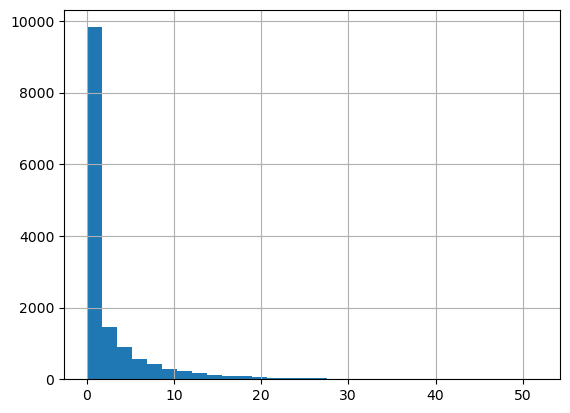

In [29]:
nis = nis[nis["513-ILLITERATE_RATE"].notna()]  # Elimina NaN
nis = nis[nis["513-ILLITERATE_RATE"] != np.inf] 
nis["513-ILLITERATE_RATE"].hist(bins=30)